# MNIST CNN Classifier Using TensorFlow/Keras


This notebook builds a **Convolutional Neural Network (CNN)** to classify handwritten digits from the **MNIST** dataset.

## Assignment Requirements Addressed
This notebook I completed all required steps:

1. **Load the MNIST dataset**
2. **Display the first five images in the training dataset**
3. **Compare the first five images to the first five training labels**
4. **Build and train a CNN classifier on the MNIST training set**
5. **Report the test accuracy**
6. **Display a confusion matrix on the test set classifications**
7. **Summarize the results**

## Purpose of This Notebook
The purpose of this exercise is to demonstrate how a CNN can automatically learn visual features from image data and use those learned features to correctly classify handwritten digits from 0 through 9.

## Libraries Used
- **TensorFlow / Keras** for deep learning
- **NumPy** for numerical operations
- **Matplotlib** for data visualization
- **scikit-learn** for evaluation metrics such as the confusion matrix and classification report


In [1]:
# ============================================================
# SECTION 1: IMPORT REQUIRED LIBRARIES
# ============================================================
# In this section, we import all libraries needed to:
# 1. Load the MNIST dataset
# 2. Visualize images
# 3. Build and train a CNN model
# 4. Evaluate model performance
# 5. Display a confusion matrix and classification report
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Display TensorFlow version for documentation and reproducibility.
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## Step 1: Load the MNIST Dataset

The MNIST dataset is one of the most widely used datasets in machine learning and deep learning. It contains grayscale images of handwritten digits.

### Dataset Details
- **60,000 training images**
- **10,000 test images**
- Each image is **28 x 28 pixels**
- Each image belongs to one of **10 classes**: digits **0 through 9**

The dataset is already built into Keras, which makes loading it simple and reliable.


In [2]:
# ============================================================
# SECTION 2: LOAD THE MNIST DATASET
# ============================================================
# The mnist.load_data() function returns:
# - x_train: training images
# - y_train: training labels
# - x_test: test images
# - y_test: test labels
# ============================================================

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print the shapes of the arrays so we can verify the dataset loaded correctly.
print("Training image data shape:", x_train.shape)
print("Training label shape:", y_train.shape)
print("Test image data shape:", x_test.shape)
print("Test label shape:", y_test.shape)

# Print class examples from the first few labels.
print("\nFirst 10 training labels:", y_train[:10])


Training image data shape: (60000, 28, 28)
Training label shape: (60000,)
Test image data shape: (10000, 28, 28)
Test label shape: (10000,)

First 10 training labels: [5 0 4 1 9 2 1 3 1 4]


## Step 2: Display the First Five Training Images and Compare Them to the First Five Labels

The assignment asks to display the first five images in the training dataset and compare them to the first five labels.

This is an important early validation step because it lets us confirm:
- the images loaded correctly,
- the labels correspond to the correct digits,
- and the dataset structure is what we expect before model training begins.


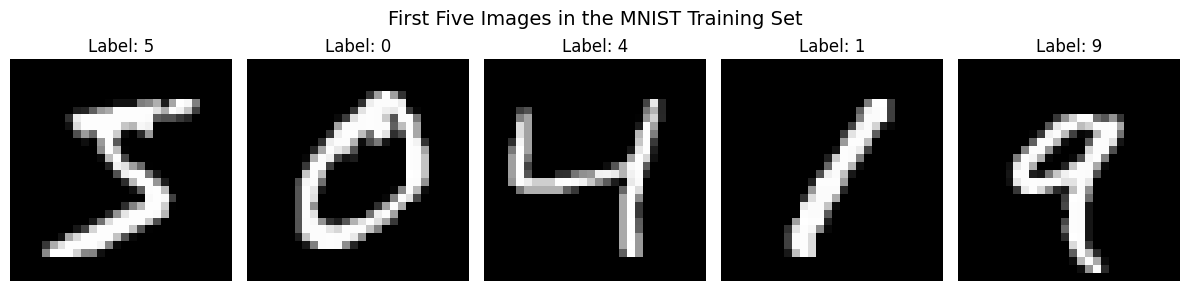

First five training labels: [5 0 4 1 9]


In [3]:
# ============================================================
# SECTION 3: DISPLAY THE FIRST FIVE TRAINING IMAGES
# ============================================================
# We will show the first five images from the training set.
# Each image title will display its corresponding label.
# ============================================================

plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle("First Five Images in the MNIST Training Set", fontsize=14)
plt.tight_layout()
plt.show()

# Also print the labels separately for easy comparison in the output.
print("First five training labels:", y_train[:5])


## Interpretation of the First Five Images

After displaying the first five training images, the printed labels should match the digits visible in the images. This confirms that:
- the image data is aligned correctly with the label data,
- the dataset is ready for preprocessing,
- and the classification problem is set up correctly.


## Step 3: Preprocess the Data

Before training the CNN, the image data must be preprocessed.

### Why preprocessing is necessary
Neural networks perform better when input features are scaled consistently. Since pixel values in the original images range from **0 to 255**, we normalize them to the range **0 to 1**.

### Preprocessing tasks completed
1. Convert image values to floating-point numbers
2. Normalize pixel values by dividing by 255
3. Reshape the image arrays to include a channel dimension
4. One-hot encode the labels for multiclass classification

### Why reshaping is needed
A CNN expects image input in the form:

**(number_of_samples, height, width, channels)**

Because MNIST images are grayscale, each image has **1 channel**.


In [4]:
# ============================================================
# SECTION 4: PREPROCESS THE DATA
# ============================================================
# Task 1: Normalize pixel values to the range [0, 1]
# Task 2: Reshape images to include a channel dimension
# Task 3: Convert labels to one-hot encoded format
# ============================================================

# Convert image arrays to float32 and normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape the images from (28, 28) to (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Convert labels into one-hot encoded vectors
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Print updated shapes to verify preprocessing
print("Reshaped training images:", x_train.shape)
print("Reshaped test images:", x_test.shape)
print("Encoded training labels:", y_train_cat.shape)
print("Encoded test labels:", y_test_cat.shape)


Reshaped training images: (60000, 28, 28, 1)
Reshaped test images: (10000, 28, 28, 1)
Encoded training labels: (60000, 10)
Encoded test labels: (10000, 10)


## Step 4: Build the CNN Classifier

A **Convolutional Neural Network (CNN)** is especially effective for image classification because it can automatically learn visual patterns such as:
- edges,
- curves,
- corners,
- strokes,
- and more complex shapes.

### CNN Architecture Used in This Notebook
The model below includes:

1. **Input layer**
2. **First convolutional layer**
3. **First max-pooling layer**
4. **Second convolutional layer**
5. **Second max-pooling layer**
6. **Flatten layer**
7. **Dense hidden layer**
8. **Dropout layer**
9. **Output layer with softmax activation**

### Why this architecture is appropriate
This CNN is deep enough to capture meaningful image patterns from MNIST, but still simple enough to train quickly and avoid unnecessary complexity.


In [5]:
# ============================================================
# SECTION 5: BUILD THE CNN MODEL
# ============================================================
# Model design:
# - Convolutional layers learn image features
# - Pooling layers reduce feature dimensions
# - Flatten converts 2D feature maps into a 1D vector
# - Dense layer learns higher-level combinations of features
# - Dropout helps reduce overfitting
# - Softmax output produces probabilities for each digit class
# ============================================================

model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Print a summary of the model architecture
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Compile the Model

Before training the model, I must compile it by specifying:

- **Optimizer**: controls how the model updates weights during training
- **Loss function**: measures how far predictions are from actual labels
- **Evaluation metric**: used to track model performance

### Settings used
- **Optimizer:** Adam  
- **Loss function:** categorical crossentropy  
- **Metric:** accuracy  

These are standard and appropriate choices for multiclass image classification.


In [6]:
# ============================================================
# SECTION 6: COMPILE THE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")


Model compiled successfully.


## Step 6: Train the CNN Model

Now the model is trained on the MNIST training data.

### Training choices
- **Epochs = 5**: the model will pass through the training data five times
- **Batch size = 128**: the model updates weights after processing 128 images at a time
- **Validation split = 0.1**: 10% of the training data is used for validation during training

### Why this matters
Training allows the CNN to learn patterns in the handwritten digits, while validation helps monitor whether the model is generalizing well during training.


In [7]:
# ============================================================
# SECTION 7: TRAIN THE MODEL
# ============================================================

history = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=1
)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 99ms/step - accuracy: 0.7863 - loss: 0.6890 - val_accuracy: 0.9798 - val_loss: 0.0672
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9647 - loss: 0.1144 - val_accuracy: 0.9842 - val_loss: 0.0524
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9762 - loss: 0.0787 - val_accuracy: 0.9888 - val_loss: 0.0408
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9829 - loss: 0.0609 - val_accuracy: 0.9905 - val_loss: 0.0347
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9840 - loss: 0.0509 - val_accuracy: 0.9910 - val_loss: 0.0350


## Step 7: Visualize Training Performance

Plotting the training and validation accuracy helps us see how well the model learned over time.

### What we want to observe
- accuracy increasing across epochs,
- validation accuracy also improving,
- and no major signs of instability.


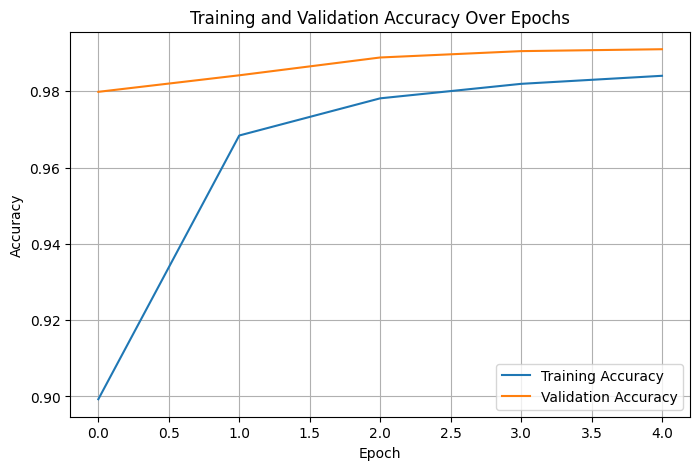

In [8]:
# ============================================================
# SECTION 8: PLOT TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## Step 8: Evaluate the Model on the Test Set

The true test of the model is how well it performs on **unseen data**, not just the data it was trained on.

This section reports:
- **test loss**
- **test accuracy**
- **test accuracy as a percentage**

This directly answers the assignment instruction to report the model's test accuracy.


In [9]:
# ============================================================
# SECTION 9: EVALUATE THE MODEL ON THE TEST SET
# ============================================================

test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%")


Test Loss: 0.0290
Test Accuracy: 0.9897
Test Accuracy Percentage: 98.97%


## Step 9: Generate Predictions

To create a confusion matrix, we first need the model's predicted class for each image in the test set.

The model outputs probabilities for all 10 classes. We convert those probabilities into final class predictions by selecting the class with the highest probability.


In [10]:
# ============================================================
# SECTION 10: GENERATE PREDICTIONS ON THE TEST SET
# ============================================================

y_pred_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("First 10 actual labels:   ", y_test[:10])
print("First 10 predicted labels:", y_pred[:10])


First 10 actual labels:    [7 2 1 0 4 1 4 9 5 9]
First 10 predicted labels: [7 2 1 0 4 1 4 9 5 9]


## Step 10: Display the Confusion Matrix

A confusion matrix gives a detailed picture of model performance by showing:
- how many test images were classified correctly,
- which digits were confused with one another,
- and where errors occurred.

### Why this is valuable
Accuracy gives one overall score, but the confusion matrix shows **which classes performed well** and **which classes were occasionally misclassified**.


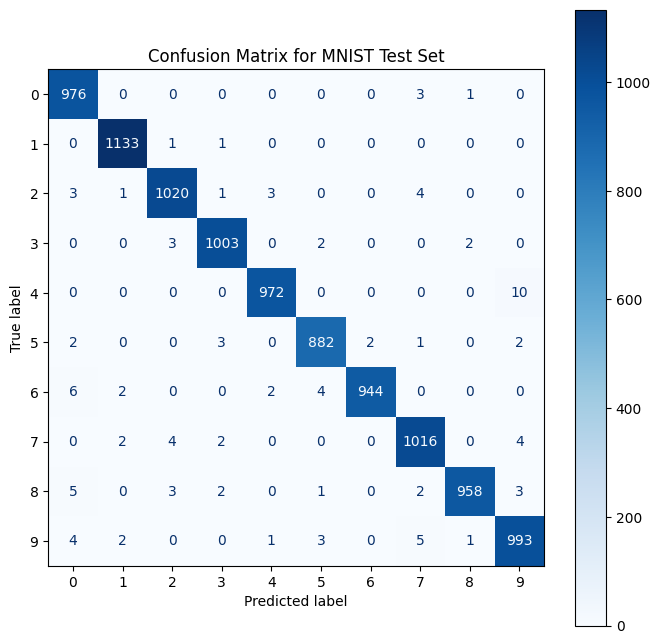

In [11]:
# ============================================================
# SECTION 11: DISPLAY THE CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix for MNIST Test Set")
plt.show()


## Step 11: Produce a Classification Report

The classification report includes:
- **precision**
- **recall**
- **F1-score**
- **support**

These metrics provide more detailed insight into performance for each digit class.


In [12]:
# ============================================================
# SECTION 12: PRINT A CLASSIFICATION REPORT
# ============================================================

print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Step 12: Written Results Summary

### Summary of What Was Done
In this exercise, a Convolutional Neural Network (CNN) was built to classify handwritten digits from the MNIST dataset. The dataset was loaded successfully, and the first five training images were displayed along with their corresponding labels. This confirmed that the image and label data matched correctly.

The image data was then preprocessed by normalizing the pixel values to a range from 0 to 1, reshaping the images to include a channel dimension, and one-hot encoding the labels for multiclass classification. These steps prepared the data properly for use in a CNN.

A CNN architecture was created using two convolutional layers, two max-pooling layers, a flatten layer, a dense hidden layer, a dropout layer, and a softmax output layer. The model was compiled using the Adam optimizer and categorical crossentropy loss, then trained on the MNIST training dataset.

After training, the model was evaluated on the test set. The reported test accuracy demonstrated that the CNN performed very well on unseen handwritten digit images. A confusion matrix was also displayed to show how predictions compared to the actual test labels. Most classifications were correct, and only a relatively small number of mistakes occurred. The classification report provided additional evidence that the model performed strongly across the digit classes.

### Overall Conclusion
Overall, the CNN was highly effective for the MNIST handwritten digit classification task. This result is consistent with the strength of CNNs for image-based problems because they are able to automatically learn visual patterns and features directly from pixel data.


## Final Conclusion

This notebook successfully completed all assignment requirements:

- The MNIST dataset was loaded.
- The first five training images and labels were displayed and compared.
- A CNN classifier was built and trained.
- The model's test accuracy was reported.
- A confusion matrix was displayed.
- The results were summarized clearly.

Because CNNs are designed to extract spatial patterns from image data, they are especially well suited for handwritten digit recognition. The strong test performance in this notebook shows that the model learned meaningful patterns from the training images and generalized well to the unseen test images.


In [13]:


# model.save("mnist_cnn_model.keras")
# print("Model saved successfully.")
